In [201]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl
import math

In [202]:
def maillage(n):
#
# Une discretisation possible d'une EDP elliptique sur le domaine ]0,1[ x ]0,1[
# Le carre [0,1]x[0,1] est maille uniquement avec des triangles; 
# Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne contient les indices 
# des sommets d'un element triangle, dans le sens antihoraire. 
# dirichlet : vecteur colonne des indices des sommets de la frontiere de
# Dirichlet.
# neumann : matrice a deux colonnes. Chaque ligne contient les indices 
# des deux sommets d'une arete de la frontiere de Neumann.
# (neumann est vide sur cet exemple)
#
##################################################################################
    h=1/(n-1)
    npoin       = n*n ; 
    nelem       = 2*(n-1)*(n-1) ;
    coordinates = np.zeros((npoin,2)); 
    elements3   = (np.zeros((nelem,3))).astype(int) ;
    neumann     = [];
    dirichlet=(np.zeros((4*n-4,1))).astype(int)
    # Coordonnees et connectivites :
    e = -1 ; 
    p = -1 ;
    x=np.zeros((n+1,1))
    x[n,0]=1.
    for l in range (n+1):
        x[l,0]=l*h
    for j in range (n):
            for i in range(n):
                p = p + 1  
                coordinates[p,0] = x[i,0]  
                coordinates[p,1] = x[j,0] 
                if ((i != n-1) & (j != n-1)):
                    p1 = p
                    p2 = p1 + 1 
                    p3 = p1 + n 
                    p4 = p2 + n 
                    e = e + 1 
                    elements3[e,0] = p1 
                    elements3[e,1] = p2 
                    elements3[e,2] = p3 
                    e = e + 1
                    elements3[e,0] = p4 
                    elements3[e,1] = p3 
                    elements3[e,2] = p2 
    #Liste des sommets de la frontiere de Dirichlet:
    p=-1
    for j in range(n):
        p=p+1
        dirichlet[p,0] = j  
    for j in range(n*2-1,n*(n-1),n):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-1,n*n-n-1,-1):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-2*n,n-1,-n):
        p=p+1
        dirichlet[p,0] = j 

    return coordinates, elements3,dirichlet, neumann

In [203]:
def show(coordinates,u):
#
# Fonction d'affichage de la solution u sur le maillage defini par
# elements3, coordinates.
#
# Entrees:
# elements3 : matrice a trois colonnes contenant les elements triangles
# de la discretisation, identifies par les indices de leurs trois
# sommets.
# coordinates : matrice a deux colonnes contenant les coordonnes 2D des
# points de la discretisation.
# u : vecteur colonne de longueur egale au nombre de lignes de
# coordinates contenant les valeurs de la solution a afficher aux
# points de la discretisation.
#
# Sorties : Aucune, mais la fonction doit s'afficher dans une figure.
##########################################################################
    ax= plt.figure().add_subplot(projection='3d')
    ax.plot_trisurf(coordinates[:,0],coordinates[:,1],u,linewidth=0.2,antialiased=True)
    plt.show()

## Partie I : maillage triangulaire et conditions de Dirichlet

### Construction matrice de raideur élémentaire

In [204]:
def Alpha(A1,A2,A3):
    return (A2[0]-A1[0])*(A3[1]-A1[1])-(A2[1]-A1[1])*(A3[0]-A1[0])

In [205]:
def M_A_T(A1,A2,A3):
    alpha = Alpha(A1,A2,A3)
    
    delta_eta = np.zeros((3,2))
    delta_eta[0] = (1/alpha)*np.array([A2[1]-A3[1],A3[0]-A2[0]])
    delta_eta[1] = (1/alpha)*np.array([A3[1]-A1[1],A1[0]-A3[0]])
    delta_eta[2] = (1/alpha)*np.array([A1[1]-A2[1],A2[0]-A1[0]])


    M = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            M[i,j] = (delta_eta[i,:].dot(np.transpose(delta_eta[j,:])))*(alpha/2)
    return M

### Assemblage de A

In [206]:
def Assemblage(coordinates,elements3):
    A = np.zeros((coordinates.shape[0],coordinates.shape[0]))
    for i in range(elements3.shape[0]):
        A1 = coordinates[elements3[i,0],:]
        A2 = coordinates[elements3[i,1],:]
        A3 = coordinates[elements3[i,2],:]
        M = M_A_T(A1,A2,A3)
        for j in range(3):
            for k in range(3):
                A[elements3[i,j],elements3[i,k]] += M[j,k]
    return A

### Assemblage de b

In [207]:
def centre_gravite(A1,A2,A3):
    return (A1 + A2 + A3)/3

In [208]:
def b(f,elements3,coordinates):
    b = np.zeros((coordinates.shape[0],1))
    for i in range(elements3.shape[0]):
        A1 = coordinates[elements3[i,0],:]
        A2 = coordinates[elements3[i,1],:]
        A3 = coordinates[elements3[i,2],:]
        C = centre_gravite(A1,A2,A3)
        for j in range(3):
            b[elements3[i,j],0] += f(C)*(Alpha(A1,A2,A3)/6)
    return b

### Condition de Dirichlet

In [209]:
def detection_dirichlet(dirichlet, A, b):
    for i in range(dirichlet.shape[0]):
        A[dirichlet[i,0],:] = 0
        A[:,dirichlet[i,0]] = 0
        A[dirichlet[i,0],dirichlet[i,0]] = 1
        b[dirichlet[i,0],0] = 0
    return A, b

### Test

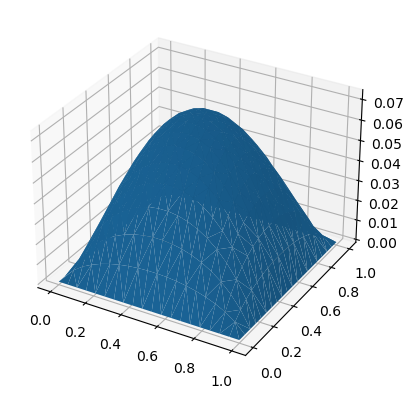

In [210]:
[coordinates, elements3, dirichlet, neumann] = maillage(20)
A = Assemblage(coordinates,elements3)
f = lambda x : 1
b = b(f,elements3,coordinates)
A_Dirichlet, b_Dirichlet = detection_dirichlet(dirichlet, A, b)
u = np.linalg.solve(A_Dirichlet, b_Dirichlet)
u = u.flatten()
show(coordinates,u)

## Partie II : maillage mixte et ajoût des conditions de Neumann

In [211]:
############################# Maillage mixte ################
e3=np.array([[1,2,12],[2,3,12],[3,4,14],[4,5,14],[2,15,3],[3,15,4]]).astype(int)
e4=np.array([[0,1,12,11],[11,12,13,10],[12,3,14,13],[10,13,8,9],[13,14,7,8],[14,5,6,7]]).astype(int)
dds=np.array([2,15,4,6,7,8,9,10,11,0]).astype(int)
nns=np.array([[4,5],[5,6],[0,1],[1,2]]).astype(int)
ccs=np.array([[0.,0.],[0.33333333333333,0],[0.53333333333333,0.],
                      [0.66666666666667,0.33333333333333],[1.,0.47],[1,0.66666666666667],
                     [1.,1.],[0.66666666666667,1.],[0.33333333333333,1.], [0.,1.],
                     [0.,0.66666666666667],[0.,0.33333333333333],[0.33333333333333,0.33333333333333],
                     [0.33333333333333,0.66666666666667],[0.66666666666667,0.66666666666667],[1.,0.]])

In [212]:
def Alpha_Q(A1,A2,A4):
    return (A2[0]-A1[0])*(A4[1]-A1[1])-(A4[0]-A1[0])*(A2[1]-A1[1])

In [213]:
def Jacobien(A1,A2,A4):
    return np.array([[A2[0]-A1[0], A4[0]-A1[0]],[A2[1]-A1[1], A4[1]-A1[1]]])

In [214]:
def inverse_jacobien(A1,A2,A4):
    J = Jacobien(A1,A2,A4)
    return (1/Alpha_Q(A1,A2,A4))*np.array([[J[1,1], -J[0,1]],[-J[1,0], J[0,0]]])

In [215]:
def grad_phi(xi, zeta):
    Grad = np.zeros((4,2))
    Grad[0] = np.array([zeta-1, xi-1])
    Grad[1] = np.array([1-zeta, -xi])
    Grad[2] = np.array([zeta, xi])
    Grad[3] = np.array([-zeta, 1-xi])
    return Grad

In [216]:
def Grad_eta(xi, zeta, A1, A2, A4):
    return inverse_jacobien(A1,A2,A4).dot(grad_phi(xi,zeta).T)

In [217]:
def M_A_Q(A1,A2,A4,xi,zeta):
    alpha = Alpha_Q(A1,A2,A4)
    
    delta_eta = Grad_eta(xi,zeta,A1,A2,A4).T

    M = np.zeros((4,4))
    for i in range(4):
        for j in range(4):
            M[i,j] = (delta_eta[i,:].dot(np.transpose(delta_eta[j,:])))*alpha
    return M

### Assemblage A

In [218]:
def Assemblage_Q(coords,elt4,xi,zeta):
    A = np.zeros((coords.shape[0],coords.shape[0]))
    for i in range(elt4.shape[0]):
        A1 = coords[elt4[i,0],:]
        A2 = coords[elt4[i,1],:]
        A4 = coords[elt4[i,3],:]
        M = M_A_Q(A1,A2,A4,xi,zeta)
        for j in range(4):
            for k in range(4):
                A[elt4[i,j],elt4[i,k]] += M[j,k]
    return A

### Assemblage b

In [219]:
def centre_gravite_Q(A1,A2,A3,A4):
    return (A1 + A2 + A3 + A4)/4

In [220]:
def b_Q(f,elt4,coords):
    b = np.zeros((coords.shape[0],1))
    for i in range(elt4.shape[0]):
        A1 = coords[elt4[i,0],:]
        A2 = coords[elt4[i,1],:]
        A3 = coords[elt4[i,2],:]
        A4 = coords[elt4[i,3],:]
        C = centre_gravite_Q(A1,A2,A3,A4)
        for j in range(4):
            b[elt4[i,j],0] += f(C)*(Alpha_Q(A1,A2,A4)/4)
    return b

### Conditions de Dirichlet

In [221]:
def detection_dirichlet_Q(dirichlet, A, b):
    for i in range(dirichlet.shape[0]):
        A[dirichlet[i],:] = 0
        A[:,dirichlet[i]] = 0
        A[dirichlet[i],dirichlet[i]] = 1
        b[dirichlet[i],0] = 0
    return A, b

### Conditions de Neumann

In [222]:
def Neumann_Q(nns, A):
    for i in range(nns.shape[0]):
        A[nns[i,0],nns[i,1]] += 1
        A[nns[i,1],nns[i,0]] += 1
    return A

### Test

(16, 16)


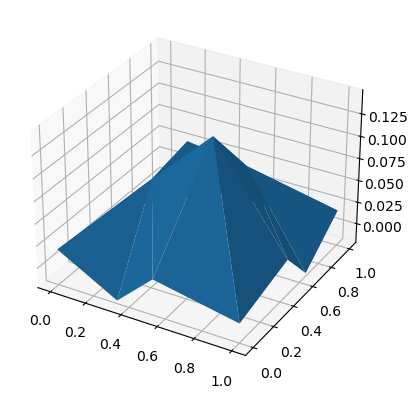

In [227]:
xi = 0.5
zeta = 0.5
A = Assemblage_Q(ccs,e4,xi,zeta)
print(A.shape)
f = lambda x : 1
b = b_Q(f,e4,ccs)
A_Dirichlet, b_Dirichlet = detection_dirichlet_Q(dds, A, b)
A_Final = Neumann_Q(nns, A_Dirichlet)
u = np.linalg.solve(A_Final, b_Dirichlet)
u = u.flatten()
show(ccs,u)

**Compléments  :  un nouveau terme dans l'EDP**